# Assistant
# Anaconda Assistant

This is a project using the Online Shoppers Purchasing Intention dataset with both TensorFlow and PyTorch. This dataset contains features of user sessions on an online shopping website, with the goal of predicting whether a user will make a purchase. Here is the dataset: https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset. 

## Project: Online Shopping Purchase Prediction

This project will demonstrate how to:
1. Load and preprocess the dataset
2. Build classification models in both TensorFlow and PyTorch
3. Evaluate and compare the models


Dataset shape: (12330, 18)

Target variable distribution:
Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64


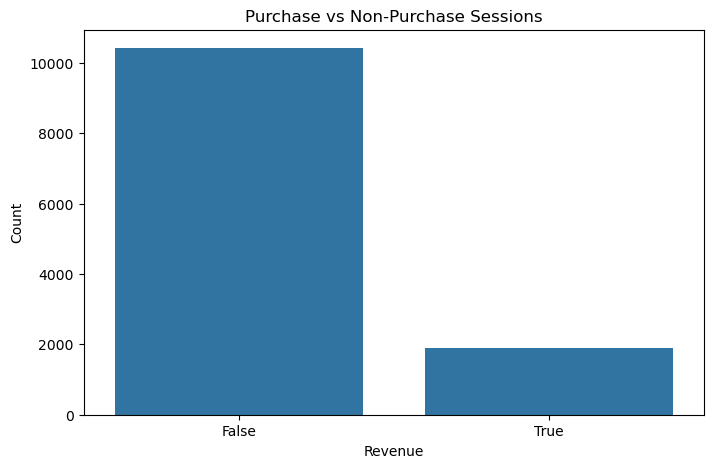


Number of features after preprocessing: 27

--- Building TensorFlow Model ---
Epoch 1/50


C:\Users\aahan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


247/247 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8459 - auc_1: 0.8056 - loss: 0.3678 - val_accuracy: 0.8855 - val_auc_1: 0.8860 - val_loss: 0.2885
Epoch 2/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8871 - auc_1: 0.8856 - loss: 0.2784 - val_accuracy: 0.8905 - val_auc_1: 0.9024 - val_loss: 0.2616
Epoch 3/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8943 - auc_1: 0.9021 - loss: 0.2620 - val_accuracy: 0.8885 - val_auc_1: 0.9091 - val_loss: 0.2590
Epoch 4/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8952 - auc_1: 0.9093 - loss: 0.2542 - val_accuracy: 0.8946 - val_auc_1: 0.9145 - val_loss: 0.2503
Epoch 5/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9004 - auc_1: 0.9149 - loss: 0.2463 - val_accuracy: 0.8951 - val_auc_1: 0.9148 - val_loss: 0.2482
Epoch 6/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8981 - auc_1: 0.9194 - loss: 0.2431 - val_accuracy: 0.8961 - val_auc_1: 0.9179 - val_loss: 0.2444
Epoch 7/50
247/247 ━━━━━━━

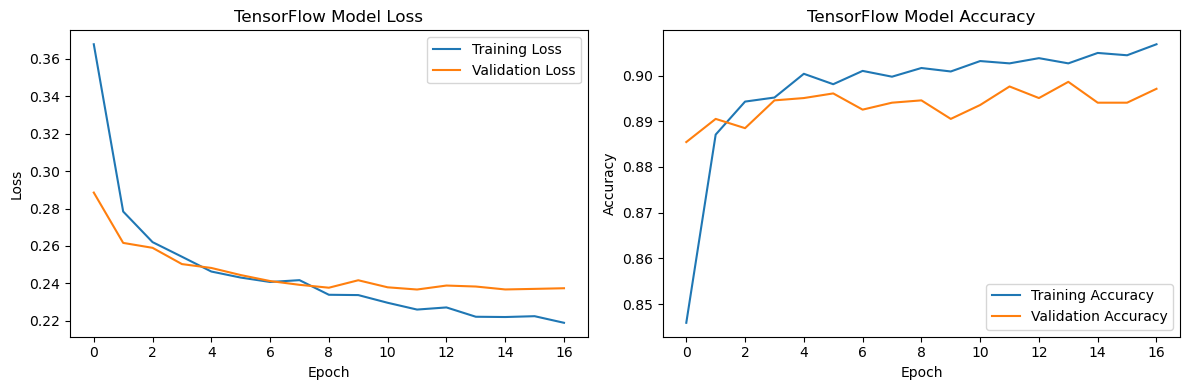

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

TensorFlow Model Results:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      2084
           1       0.69      0.58      0.63       382

    accuracy                           0.89      2466
   macro avg       0.81      0.77      0.78      2466
weighted avg       0.89      0.89      0.89      2466


--- Building PyTorch Model ---
Using device: cpu

Starting PyTorch Training...

Epoch 1/30 | Train Loss: 0.3331 | Val Loss: 0.2756
Epoch 2/30 | Train Loss: 0.2584 | Val Loss: 0.2592
Epoch 3/30 | Train Loss: 0.2540 | Val Loss: 0.2552
Epoch 4/30 | Train Loss: 0.2440 | Val Loss: 0.2526
Epoch 5/30 | Train Loss: 0.2417 | Val Loss: 0.2505
Epoch 6/30 | Train Loss: 0.2365 | Val Loss: 0.2543
Epoch 7/30 | Train Loss: 0.2327 | Val Loss: 0.2488
Epoch 8/30 | Train Loss: 0.2285 | Val Loss: 0.2455
Epoch 9/30 | Train Loss: 0.2302 | Val Loss: 0.2505
Epoch 10/30 | Train Loss: 0.2261 | Val Loss: 0.2450
Epoch 11/30 | T

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report

# For deep learning
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ====================== DATA LOADING & PREPROCESSING ======================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
data = pd.read_csv(url)

# Exploratory Data Analysis
print("Dataset shape:", data.shape)
print("\nTarget variable distribution:")
print(data['Revenue'].value_counts(normalize=True))

# Visualize class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Revenue', data=data)
plt.title('Purchase vs Non-Purchase Sessions')
plt.ylabel('Count')
plt.show()

# Data Preprocessing
X = data.drop('Revenue', axis=1)
y = data['Revenue'].astype(int)

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

n_features = X_train_processed.shape[1]
print(f"\nNumber of features after preprocessing: {n_features}")

# ====================== TENSORFLOW MODEL ======================

print("\n--- Building TensorFlow Model ---")

def build_tf_model(n_features):
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(n_features,)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC()])
    return model

tf_model = build_tf_model(n_features)
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

tf_history = tf_model.fit(
    X_train_processed, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Plot TensorFlow training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(tf_history.history['loss'], label='Training Loss')
plt.plot(tf_history.history['val_loss'], label='Validation Loss')
plt.title('TensorFlow Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(tf_history.history['accuracy'], label='Training Accuracy')
plt.plot(tf_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('TensorFlow Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate TensorFlow model
y_pred_proba_tf = tf_model.predict(X_test_processed)
y_pred_tf = (y_pred_proba_tf > 0.5).astype(int)
print("\nTensorFlow Model Results:")
print(classification_report(y_test, y_pred_tf))

# ====================== PYTORCH MODEL ======================

print("\n--- Building PyTorch Model ---")

class ShopperDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32).reshape(-1, 1)
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

train_dataset = ShopperDataset(X_train_processed, y_train.values)
test_dataset = ShopperDataset(X_test_processed, y_test.values)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class PurchasePredictor(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.layer1 = nn.Linear(n_features, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.layer2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.layer3 = nn.Linear(64, 32)
        self.layer4 = nn.Linear(32, 1)
        
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.dropout2 = nn.Dropout(0.2)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.dropout1(self.bn1(self.relu(self.layer1(x))))
        x = self.dropout2(self.bn2(self.relu(self.layer2(x))))
        x = self.relu(self.layer3(x))
        x = self.sigmoid(self.layer4(x))
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch_model = PurchasePredictor(n_features).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(torch_model.parameters(), lr=0.001)

# ====================== FIXED PYTORCH TRAINING LOOP ======================

num_epochs = 30
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 5
counter = 0

print("\nStarting PyTorch Training...\n")

for epoch in range(num_epochs):
    # Training
    torch_model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = torch_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()           # ← Fixed
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    torch_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = torch_model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(test_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

print("\nPyTorch Training Completed!")

# PyTorch Evaluation
torch_model.eval()
y_pred_proba_torch = []
with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = torch_model(inputs)
        y_pred_proba_torch.extend(outputs.cpu().numpy())

y_pred_proba_torch = np.array(y_pred_proba_torch)
y_pred_torch = (y_pred_proba_torch > 0.5).astype(int)

print("\nPyTorch Model Results:")
print(classification_report(y_test, y_pred_torch))